In [1]:
### import

import numpy as np
import matplotlib.pyplot as plt
from neurodiffeq.conditions import IVP
from neurodiffeq.solvers import Solver2D
from neurodiffeq.monitors import Monitor2D
from neurodiffeq.generators import Generator2D
import torch
from neurodiffeq import diff      # the differentiation operation
from neurodiffeq.ode import solve # the ANN-based solver
from neurodiffeq.conditions import IVP   # the initial condition
from neurodiffeq.networks import FCNN    # fully-connect neural network
from neurodiffeq.networks import SinActv # sin activation

c:\Users\Etudiant\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
## PINN training 1 without ff, with BC
## first stage of SIPN method
## With neurodiffeq 5 outputs directly works for the first stage


from neurodiffeq.networks import FCNN
from neurodiffeq.generators import Generator2D
from neurodiffeq.operators import diff
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

# Definition of a multi-head network
class MultiHeadFCNN(nn.Module):
    def __init__(self, n_input_units=2, n_output_units=1, hidden_units=[256, 256]):
        super().__init__()
        # Shared layers
        self.shared_layers = nn.Sequential(
            nn.Linear(n_input_units, hidden_units[0]),
            nn.Tanh(),
            nn.Linear(hidden_units[0], hidden_units[1]),
            nn.Tanh()
        )
        # Separate heads
        self.head1 = nn.Linear(hidden_units[1], n_output_units)
        self.head2 = nn.Linear(hidden_units[1], n_output_units)
    
    def forward(self, x, head_idx=0):
        shared = self.shared_layers(x)
        if head_idx == 0:
            return self.head1(shared)
        else:
            return self.head2(shared)

total_losses = []
pde_losses = []
ic_losses = []
bc_losses = []  # New: to track boundary conditions loss

# Single mu parameter
mu = 0.3

# Initial and boundary conditions
initial_conditions = [
    # Head 0
    {
        'rho': lambda x: 2+torch.sin(x),
        'v': lambda x: x,
        'P': lambda x: torch.exp(-x),
        'By': lambda x: torch.exp(-x),
        'Bz': lambda x: torch.exp(-x)
    },
    # Head 1 
    {
        'rho': lambda x: 2+torch.sin(x),
        'v': lambda x: x*x*x,
        'P': lambda x: torch.exp(-x),
        'By': lambda x: torch.exp(-x),
        'Bz': lambda x: torch.exp(-x) 
    }
]

# New: Boundary conditions (common to both heads)
def boundary_conditions(x, t):
    """Returns target values for x=0"""
    return {
        'rho': 2.0 * torch.ones_like(x),
        'v': torch.zeros_like(x),
        'P': torch.exp(-t),
        'By': torch.exp(-t),
        'Bz': torch.exp(-t)

    }

# PDE system
def pde_system(rho, v, P, By, Bz, x, t, head_idx):
    return [
        diff(rho, t) + v * diff(rho, x) + rho * diff(v, x),
        rho * diff(v, t) + rho * v * diff(v, x) + diff(P, x) - rho * mu * diff(v, x, order=2),
        diff(P, t) + P * diff(v, x) + v * diff(P, x)
    ]

# Network creation
nets = [MultiHeadFCNN(n_input_units=2, n_output_units=1, hidden_units=[256, 256]) for _ in range(5)]

# Optimizer
params = [p for net in nets for p in net.parameters()]
optimizer = optim.Adam(params, lr=1e-4)
criterion = nn.MSELoss()

# Generators
train_gen = Generator2D((20, 20), xy_min=(0, 0), xy_max=(1, 1), method='equally-spaced-noisy')
bc_gen = Generator2D((20, 20), xy_min=(0, 0), xy_max=(0, 1), method='equally-spaced')  # Points at boundary x=0
ic_x = torch.linspace(0, 1, 128).view(-1, 1)
ic_t = torch.zeros_like(ic_x)

# Training loop
for epoch in tqdm(range(12000)):
    optimizer.zero_grad()
    total_loss = 0
    epoch_pde_loss = 0
    epoch_ic_loss = 0
    epoch_bc_loss = 0  # New: boundary conditions loss
    
    for head_idx in range(len(initial_conditions)):
        # 1. PDE Loss
        samples = train_gen.get_examples()
        x_train = samples[0].view(-1, 1)
        t_train = samples[1].view(-1, 1)
        inputs = torch.cat((x_train, t_train), dim=1)

        outputs = [net(inputs, head_idx=head_idx) for net in nets]
        pde_residuals = pde_system(*outputs, x_train, t_train, head_idx)
        loss_pde = sum([criterion(residual, torch.zeros_like(residual)) for residual in pde_residuals])
        epoch_pde_loss += loss_pde.item()

        # 2. Initial condition loss
        ic_inputs = torch.cat((ic_x, ic_t), dim=1)
        ic_outputs = [net(ic_inputs, head_idx=head_idx) for net in nets]
        ic_targets = [
            initial_conditions[head_idx]['rho'](ic_x),
            initial_conditions[head_idx]['v'](ic_x),
            initial_conditions[head_idx]['P'](ic_x),
            initial_conditions[head_idx]['By'](ic_x),
            initial_conditions[head_idx]['Bz'](ic_x)
        ]
        loss_ic = sum([criterion(out, target) for out, target in zip(ic_outputs, ic_targets)])
        epoch_ic_loss += loss_ic.item()

        # 3. New: Boundary condition loss (x=0)
        bc_samples = bc_gen.get_examples()
        x_bc = torch.zeros_like(bc_samples[0]).view(-1, 1)  # x=0
        t_bc = bc_samples[1].view(-1, 1)
        bc_inputs = torch.cat((x_bc, t_bc), dim=1)
        
        bc_outputs = [net(bc_inputs, head_idx=head_idx) for net in nets]
        bc_targets = boundary_conditions(x_bc, t_bc)
        loss_bc = (
            criterion(bc_outputs[0], bc_targets['rho']) +  # rho
            criterion(bc_outputs[1], bc_targets['v']) +    # v
            criterion(bc_outputs[2], bc_targets['P']) +    # P
            criterion(bc_outputs[3], bc_targets['By']) +   # By
            criterion(bc_outputs[4], bc_targets['Bz'])     # Bz
        )
        epoch_bc_loss += loss_bc.item()

        total_loss += loss_pde + loss_ic + loss_bc  # Now includes BC loss
    
    total_loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        n_heads = len(initial_conditions)
        print(
            f"Epoch {epoch} | "
            f"PDE: {epoch_pde_loss/n_heads:.3e} | "
            f"IC: {epoch_ic_loss/n_heads:.3e} | "
            f"BC: {epoch_bc_loss/n_heads:.3e} | "  # New: BC display
            f"Total: {total_loss.item()/n_heads:.3e}"
        )
    
    total_losses.append(total_loss.item() / len(initial_conditions))
    pde_losses.append(epoch_pde_loss / len(initial_conditions))
    ic_losses.append(epoch_ic_loss / len(initial_conditions))
    bc_losses.append(epoch_bc_loss / len(initial_conditions))  # Store BC loss

def solutions(x, t, head_idx=0):
    inputs = torch.cat((x, t), dim=1)
    return [net(inputs, head_idx=head_idx).detach() for net in nets]

  0%|          | 2/12000 [00:00<41:44,  4.79it/s]

Epoch 0 | PDE: 3.754e-02 | IC: 8.596e+00 | BC: 5.905e+00 | Total: 1.454e+01


  1%|          | 102/12000 [00:16<27:16,  7.27it/s]

Epoch 100 | PDE: 3.216e-02 | IC: 1.519e-01 | BC: 6.910e-02 | Total: 2.532e-01


  2%|▏         | 202/12000 [00:31<28:25,  6.92it/s]

...

 98%|█████████▊| 11801/12000 [34:44<00:43,  4.61it/s]

Epoch 11800 | PDE: 4.076e-03 | IC: 9.726e-04 | BC: 4.486e-03 | Total: 9.535e-03


 99%|█████████▉| 11901/12000 [35:05<00:19,  5.06it/s]

Epoch 11900 | PDE: 1.738e-03 | IC: 1.099e-03 | BC: 3.908e-03 | Total: 6.744e-03


100%|██████████| 12000/12000 [35:25<00:00,  5.64it/s]


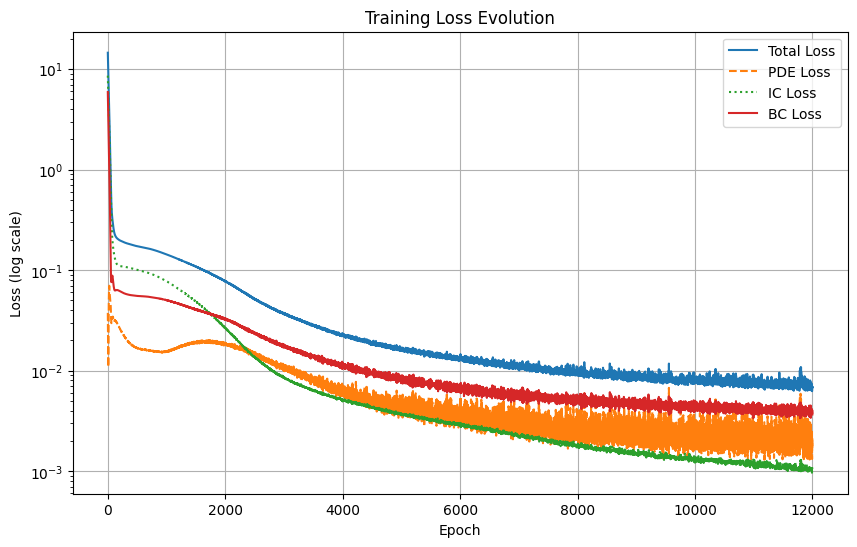

In [3]:
## Loss function

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.semilogy(total_losses, label='Total Loss')
plt.semilogy(pde_losses, label='PDE Loss', linestyle='--')
plt.semilogy(ic_losses, label='IC Loss', linestyle=':')
plt.semilogy(bc_losses, label='BC Loss', linestyle='-')


plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Training Loss Evolution')
plt.legend()
plt.grid(True)
plt.show()

Weights type of the first network: torch.float64


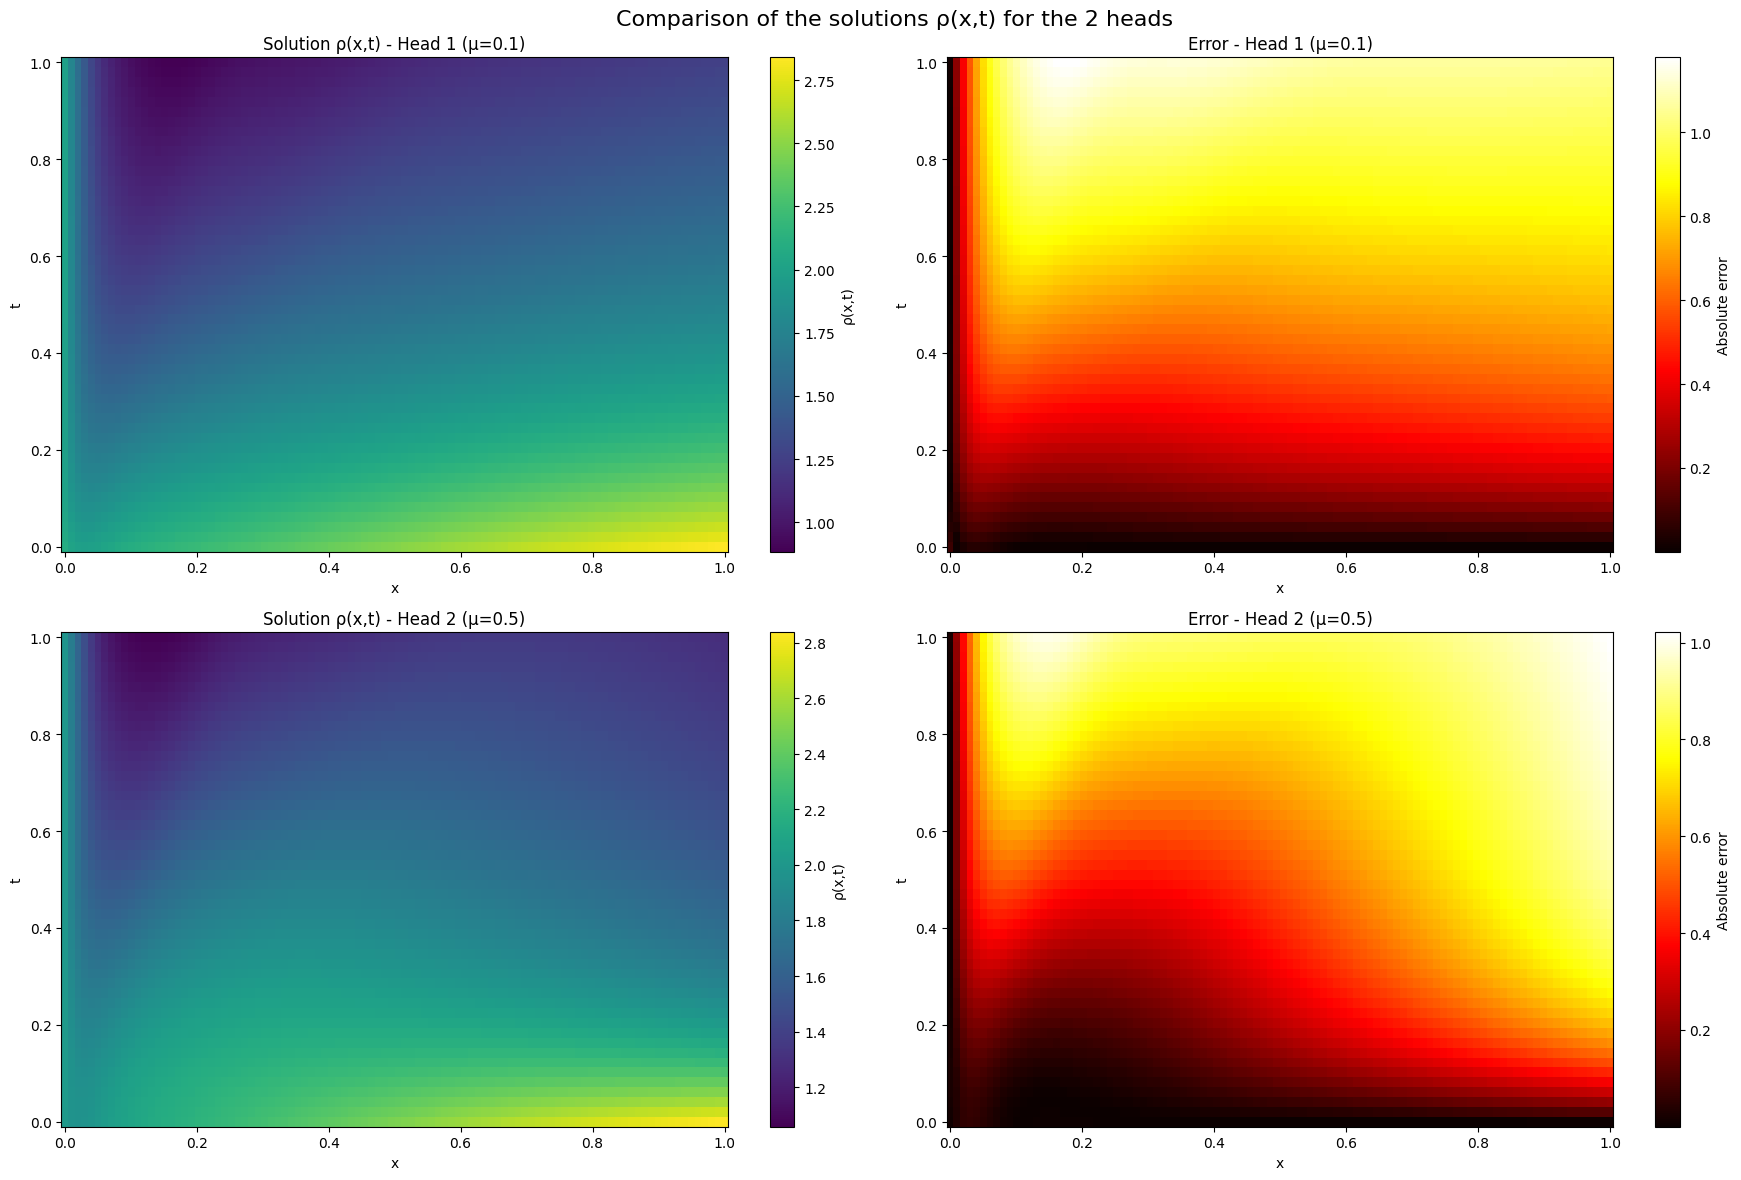

Max error head 1 (μ=0.1): 1.179e+00
Max error head 2 (μ=0.5): 1.021e+00


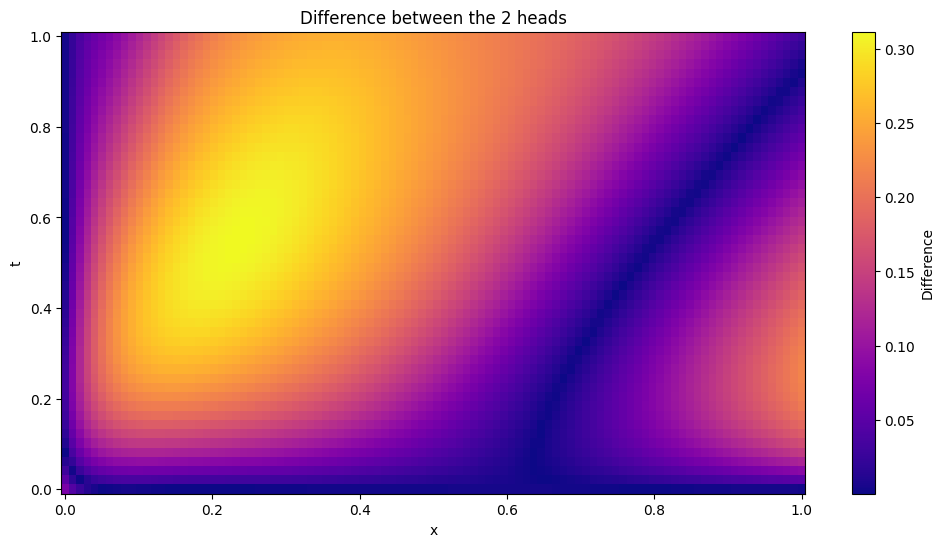

In [4]:
## show rho for 2 heads
## output shown can be changed

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import torch

# 1. Check data types
print(f"Weights type of the first network: {next(nets[0].parameters()).dtype}")

# 2. Meshgrid creation
x = np.linspace(0, 1, 100).astype(np.float32)
t = np.linspace(0, 1, 50).astype(np.float32)
X, T = np.meshgrid(x, t)

# 3. Conversion to PyTorch tensors
x_tensor = torch.tensor(X.flatten(), dtype=torch.float32).view(-1, 1)
t_tensor = torch.tensor(T.flatten(), dtype=torch.float32).view(-1, 1)

# 4. Calculation of solutions for both heads
try:
    with torch.no_grad():
        # Check and convert if necessary
        if next(nets[0].parameters()).dtype != torch.float32:
            for net in nets:
                net.float()
        
        # Calculation for both heads
        sols_head1 = solutions(x_tensor, t_tensor, head_idx=0)  # mu=0.1
        sols_head2 = solutions(x_tensor, t_tensor, head_idx=1)  # mu=0.5
        
        rho_head1 = sols_head1[0].cpu().numpy().reshape(X.shape)
        rho_head2 = sols_head2[0].cpu().numpy().reshape(X.shape)
        
except Exception as e:
    print(f"Error during calculation: {str(e)}")
    raise

# Analytical solution
rho_analytical = 2+ np.sin(X) * np.exp(-T)

# Error calculation
error_head1 = np.abs(rho_analytical - rho_head1)
error_head2 = np.abs(rho_analytical - rho_head2)

# Create a figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Comparison of the solutions ρ(x,t) for the 2 heads', fontsize=16)

# Plot for mu=0.1
im1 = axes[0,0].pcolormesh(X, T, rho_head1, shading='auto', cmap='viridis')
fig.colorbar(im1, ax=axes[0,0], label='ρ(x,t)')
axes[0,0].set_title('Solution ρ(x,t) - Head 1 ')
axes[0,0].set_xlabel('x')
axes[0,0].set_ylabel('t')

# Error for mu=0.1
im2 = axes[0,1].pcolormesh(X, T, error_head1, shading='auto', cmap='hot')
fig.colorbar(im2, ax=axes[0,1], label='Absolute error')
axes[0,1].set_title('Error - Head 1 ')
axes[0,1].set_xlabel('x')
axes[0,1].set_ylabel('t')

# Plot for mu=0.5
im3 = axes[1,0].pcolormesh(X, T, rho_head2, shading='auto', cmap='viridis')
fig.colorbar(im3, ax=axes[1,0], label='ρ(x,t)')
axes[1,0].set_title('Solution ρ(x,t) - Head 2 ')
axes[1,0].set_xlabel('x')
axes[1,0].set_ylabel('t')

# Error for mu=0.5
im4 = axes[1,1].pcolormesh(X, T, error_head2, shading='auto', cmap='hot')
fig.colorbar(im4, ax=axes[1,1], label='Absolute error')
axes[1,1].set_title('Error - Head 2')
axes[1,1].set_xlabel('x')
axes[1,1].set_ylabel('t')

plt.tight_layout()
plt.show()

# Display maximum errors for comparison
print(f"Max error head 1: {np.max(error_head1):.3e}")
print(f"Max error head 2: {np.max(error_head2):.3e}")

# Optional: Difference between the two heads
diff_heads = np.abs(rho_head1 - rho_head2)
plt.figure(figsize=(12, 6))
plt.pcolormesh(X, T, diff_heads, shading='auto', cmap='plasma')
plt.colorbar(label='Difference')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Difference between the 2 heads')
plt.show()
print()

In [5]:
## save weights of the 5 first NN

import os
os.makedirs("saved_weights", exist_ok=True)  


for i, net in enumerate(nets[:5]):
    torch.save(net.state_dict(), f"saved_weights/net_{i}.pt")


In [6]:
### training 2 without ff, with BC

from neurodiffeq.networks import FCNN
from neurodiffeq.generators import Generator2D
from neurodiffeq.operators import diff
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim

# Definition of a multi-head network
class MultiHeadFCNN(nn.Module):
    def __init__(self, n_input_units=2, n_output_units=1, hidden_units=[256, 256]):
        super().__init__()
        # Shared layers
        self.shared_layers = nn.Sequential(
            nn.Linear(n_input_units, hidden_units[0]),
            nn.Tanh(),
            nn.Linear(hidden_units[0], hidden_units[1]),
            nn.Tanh()
        )
        # Separate heads
        self.head1 = nn.Linear(hidden_units[1], n_output_units)
        self.head2 = nn.Linear(hidden_units[1], n_output_units)
    
    def forward(self, x, head_idx=0):
        shared = self.shared_layers(x)
        if head_idx == 0:
            return self.head1(shared)
        else:
            return self.head2(shared)

total_losses = []
pde_losses = []
ic_losses = []

# Single mu parameter
mu = 0.3  # Fixed value for mu

# Definition of initial conditions for each head
initial_conditions = [
    # Head 0 - Original ICs
    {
        'rho': lambda x: 2+torch.sin(x),
        'v': lambda x: x,
        'P': lambda x: torch.exp(-x),
        'By': lambda x: torch.exp(-x),
        'Bz': lambda x: torch.exp(-x),
        'vy': lambda x: x,
        'vz': lambda x: x,
        'Bx': lambda x: torch.exp(-x)
    },
    # Head 1 - New ICs
    {
        'rho': lambda x: 2+torch.sin(x),
        'v': lambda x: x*x*x,
        'P': lambda x: torch.exp(-x),
        'By': lambda x: torch.exp(-x),
        'Bz': lambda x: torch.exp(-x),
        'vy': lambda x: x*x*x,  
        'vz': lambda x: x*x*x,
        'Bx': lambda x: torch.exp(-x)
    }
]

# New: Boundary conditions (common to both heads)
def boundary_conditions(x, t):
    """Returns target values for x=0"""
    return {
        'rho': 2.0 * torch.ones_like(x),
        'v': torch.zeros_like(x),
        'P': torch.exp(-t),
        'By': torch.exp(-t),
        'Bz': torch.exp(-t),
        'vy': torch.zeros_like(x),
        'vz': torch.zeros_like(x),
        'Bx': torch.exp(-t),
    }

# PDE system adapted for 8 equations
def pde_system(rho, vx, P, By, Bz, vy, vz, Bx, x, t, head_idx):
   
    return [
        diff(rho, t) + vx * diff(rho, x) + rho * diff(vx, x) ,  # Equation 1
        rho * diff(vx, t) + rho * vx * diff(vx, x) + diff(P, x) + By * diff(By, x) + Bz * diff(Bz, x) - rho * mu * diff(vx, x, order=2)  ,  # Equation 2
        rho * diff(vy,t) + rho*vx*diff(vy,x) - Bx*diff(By,x) ,  # Equation 3
        rho * diff(vz,t) + rho*vx*diff(vz,x) - Bx*diff(Bz,x) ,  # New Equation 4
        diff(P,t) + P*diff(vx,x) + vx*diff(P,x),  # New Equation 5
        diff(Bx,t),  # New Equation 6
        diff(By,t) + vx*diff(By,x) + By*diff(vx,x) - Bx*diff(vy,x) ,  # New Equation 7
        diff(Bz,t) + vx*diff(Bz,x) + Bz*diff(vx,x) - Bx*diff(vz,x)  # New Equation 8
    ]

# Creation of 8 networks
nets = [MultiHeadFCNN(n_input_units=2, n_output_units=1, hidden_units=[256, 256]) for _ in range(8)]

# Loading saved weights for the first 5 networks
for i in range(5):
    net_path = f"saved_weights/net_{i}.pt"
    if os.path.exists(net_path):
        nets[i].load_state_dict(torch.load(net_path))
        #print(f"Weights loaded for network {i} from {net_path}")
    else:
        #print(f"Warning: File {net_path} not found. Random initialization.")
        def init_weights(m):
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
        nets[i].apply(init_weights)

# Initialization of new networks (5 to 7) with random weights
for i in range(5, 8):
    def init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
    nets[i].apply(init_weights)
    #print(f"Network {i} initialized with random weights")

# Optimizer
params = [p for net in nets for p in net.parameters()]
optimizer = optim.Adam(params, lr=1e-4)
criterion = nn.MSELoss()
##define the exponential learning rate decay scheduler
step_size = 500 ##how often the exponential decay is applied
gamma = 0.975 ##exponential decay scale
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)


# Generators
train_gen = Generator2D((20, 20), xy_min=(0, 0), xy_max=(1, 1), method='equally-spaced-noisy')
ic_x = torch.linspace(0, 1, 128).view(-1, 1)
ic_t = torch.zeros_like(ic_x)

# Training loop
for epoch in tqdm(range(12000)):
    optimizer.zero_grad()
    total_loss = 0
    epoch_pde_loss = 0
    epoch_ic_loss = 0
    
    # For each head
    for head_idx in range(len(initial_conditions)):
        # 1. PDE Loss
        samples = train_gen.get_examples()
        x_train = samples[0].view(-1, 1)
        t_train = samples[1].view(-1, 1)
        inputs = torch.cat((x_train, t_train), dim=1)

        # Using specific head
        outputs = [net(inputs, head_idx=head_idx) for net in nets]
        pde_residuals = pde_system(*outputs, x_train, t_train, head_idx)

        loss_pde = sum([criterion(residual, torch.zeros_like(residual)) for residual in pde_residuals])
        epoch_pde_loss += loss_pde.item()

        # 2. Initial condition loss
        ic_inputs = torch.cat((ic_x, ic_t), dim=1)
        ic_outputs = [net(ic_inputs, head_idx=head_idx) for net in nets]
        ic_targets = [
            initial_conditions[head_idx]['rho'](ic_x),
            initial_conditions[head_idx]['v'](ic_x),
            initial_conditions[head_idx]['P'](ic_x),
            initial_conditions[head_idx]['By'](ic_x),
            initial_conditions[head_idx]['Bz'](ic_x),
            initial_conditions[head_idx]['vy'](ic_x),
            initial_conditions[head_idx]['vz'](ic_x),
            initial_conditions[head_idx]['Bx'](ic_x)
        ]

        loss_ic = sum([criterion(out, target) for out, target in zip(ic_outputs, ic_targets)])
        epoch_ic_loss += loss_ic.item()

        # 3. New: Boundary condition loss (x=0)
        bc_samples = bc_gen.get_examples()
        x_bc = torch.zeros_like(bc_samples[0]).view(-1, 1)  # x=0
        t_bc = bc_samples[1].view(-1, 1)
        bc_inputs = torch.cat((x_bc, t_bc), dim=1)
        
        bc_outputs = [net(bc_inputs, head_idx=head_idx) for net in nets]
        bc_targets = boundary_conditions(x_bc, t_bc)
        loss_bc = (
            criterion(bc_outputs[0], bc_targets['rho']) +  # rho
            criterion(bc_outputs[1], bc_targets['v']) +    # v
            criterion(bc_outputs[2], bc_targets['P']) +    # P
            criterion(bc_outputs[3], bc_targets['By']) +   # By
            criterion(bc_outputs[4], bc_targets['Bz']) +    # Bz
            criterion(bc_outputs[5], bc_targets['vy']) + # vy
            criterion(bc_outputs[6], bc_targets['vz']) +  # vz
            criterion(bc_outputs[7], bc_targets['Bx'])    # Bx
        )
        epoch_bc_loss += loss_bc.item()

        total_loss += loss_pde + loss_ic + loss_bc  # Now includes BC loss
    
    total_loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        n_heads = len(initial_conditions)
        print(
            f"Epoch {epoch} | "
            f"PDE: {epoch_pde_loss/n_heads:.3e} | "
            f"IC: {epoch_ic_loss/n_heads:.3e} | "
            f"BC: {epoch_bc_loss/n_heads:.3e} | "  # New: BC display
            f"Total: {total_loss.item()/n_heads:.3e}"
        )
    
    total_losses.append(total_loss.item() / len(initial_conditions))
    pde_losses.append(epoch_pde_loss / len(initial_conditions))
    ic_losses.append(epoch_ic_loss / len(initial_conditions))
    bc_losses.append(epoch_bc_loss / len(initial_conditions))  # Store BC loss

def solutions(x, t, head_idx=0):
    inputs = torch.cat((x, t), dim=1)
    return [net(inputs, head_idx=head_idx).detach() for net in nets]

  0%|          | 1/12000 [00:00<1:08:54,  2.90it/s]

Epoch 0 | PDE: 1.437e+00 | IC: 8.930e-01 | BC: 4.737e-01 | Total: 2.800e+00


  1%|          | 101/12000 [00:33<1:13:53,  2.68it/s]

Epoch 100 | PDE: 5.343e-02 | IC: 1.905e-01 | BC: 2.925e+01 | Total: 4.022e-01


  2%|▏         | 201/12000 [01:05<56:00,  3.51it/s]  

...

 98%|█████████▊| 11801/12000 [1:14:27<01:10,  2.83it/s]

Epoch 11800 | PDE: 1.125e-02 | IC: 2.334e-03 | BC: 2.435e+02 | Total: 2.248e-02


 99%|█████████▉| 11901/12000 [1:15:03<00:33,  2.97it/s]

Epoch 11900 | PDE: 1.081e-02 | IC: 2.493e-03 | BC: 2.444e+02 | Total: 2.230e-02


100%|██████████| 12000/12000 [1:15:39<00:00,  2.64it/s]


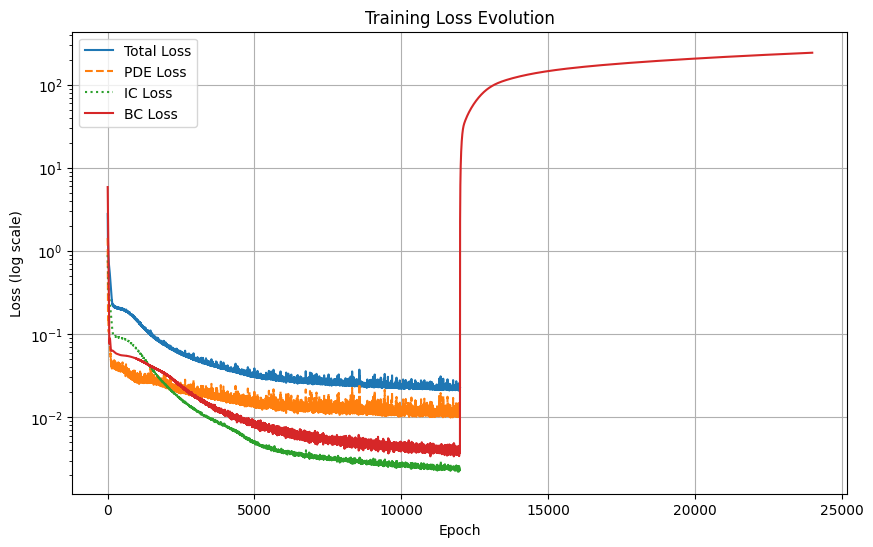

In [7]:
### loss function
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.semilogy(total_losses, label='Total Loss')
plt.semilogy(pde_losses, label='PDE Loss', linestyle='--')
plt.semilogy(ic_losses, label='IC Loss', linestyle=':')
plt.semilogy(bc_losses, label='BC Loss', linestyle='-')


plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Training Loss Evolution')
plt.legend()
plt.grid(True)
plt.show()

Weight type of the first network: torch.float64


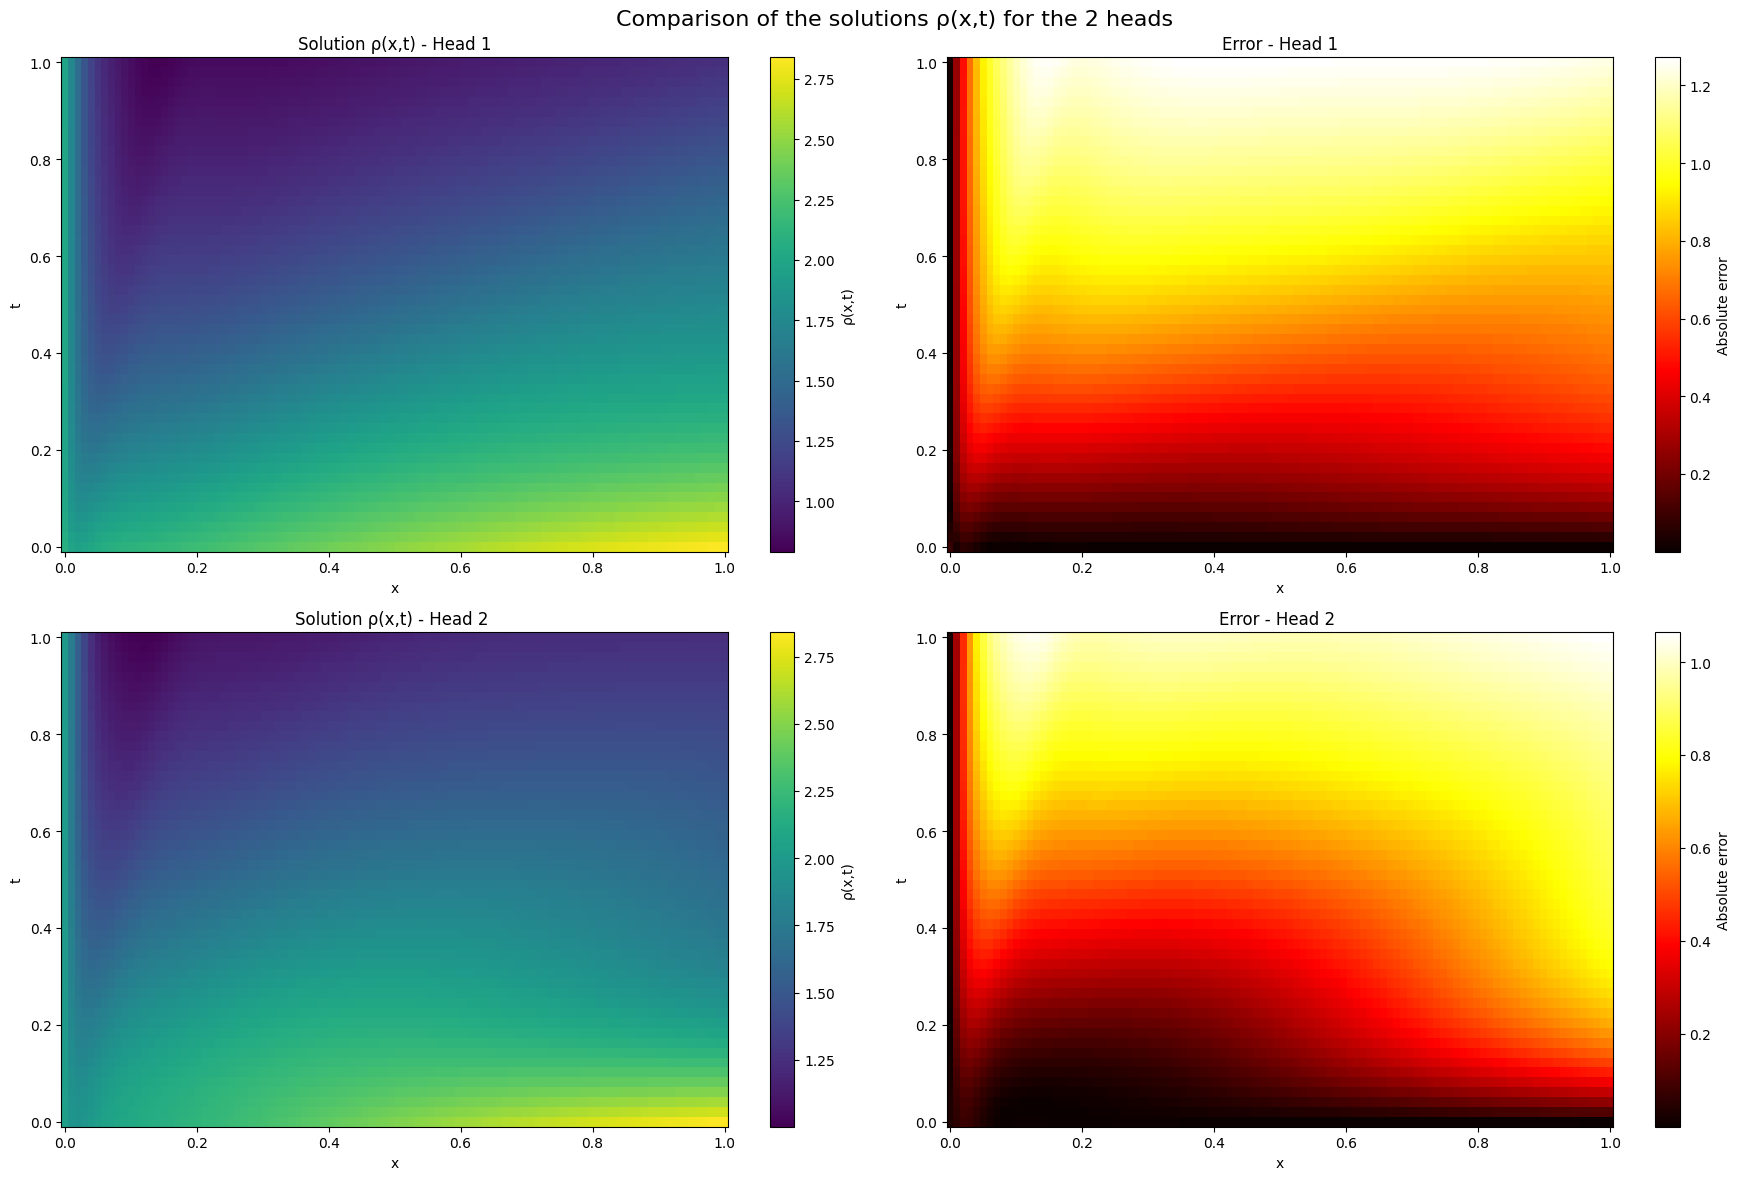

Max error head 1 : 1.272e+00
Max error head 2 : 1.064e+00


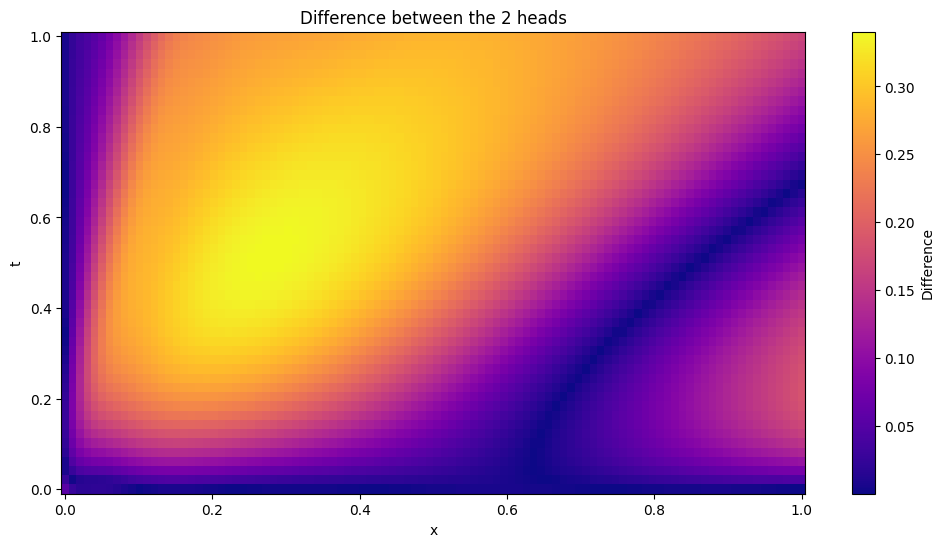

In [8]:
## show rho for 2 heads
## output shown can be changed

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import torch

# 1. Data type verification
print(f"Weight type of the first network: {next(nets[0].parameters()).dtype}")

# 2. Meshgrid creation
x = np.linspace(0, 1, 100).astype(np.float32)
t = np.linspace(0, 1, 50).astype(np.float32)
X, T = np.meshgrid(x, t)

# 3. Conversion to PyTorch tensors
x_tensor = torch.tensor(X.flatten(), dtype=torch.float32).view(-1, 1)
t_tensor = torch.tensor(T.flatten(), dtype=torch.float32).view(-1, 1)

# 4. Solution calculation for the two heads
try:
    with torch.no_grad():
        # Check and convert if necessary
        if next(nets[0].parameters()).dtype != torch.float32:
            for net in nets:
                net.float()
        
        # Calculation for the two heads
        sols_head1 = solutions(x_tensor, t_tensor, head_idx=0)  # head1
        sols_head2 = solutions(x_tensor, t_tensor, head_idx=1)  # head2
        
        rho_head1 = sols_head1[0].cpu().numpy().reshape(X.shape)
        rho_head2 = sols_head2[0].cpu().numpy().reshape(X.shape)
        
except Exception as e:
    print(f"Error during calculation: {str(e)}")
    raise

# Analytical solution
rho_analytical = 2+ np.sin(X) * np.exp(-T)

# Error calculation
error_head1 = np.abs(rho_analytical - rho_head1)
error_head2 = np.abs(rho_analytical - rho_head2)

# Create a figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Comparison of the solutions ρ(x,t) for the 2 heads', fontsize=16)

# Plot for mu=0.1
im1 = axes[0,0].pcolormesh(X, T, rho_head1, shading='auto', cmap='viridis')
fig.colorbar(im1, ax=axes[0,0], label='ρ(x,t)')
axes[0,0].set_title('Solution ρ(x,t) - Head 1')
axes[0,0].set_xlabel('x')
axes[0,0].set_ylabel('t')

# Error for mu=0.1
im2 = axes[0,1].pcolormesh(X, T, error_head1, shading='auto', cmap='hot')
fig.colorbar(im2, ax=axes[0,1], label='Absolute error')
axes[0,1].set_title('Error - Head 1')
axes[0,1].set_xlabel('x')
axes[0,1].set_ylabel('t')

# Plot for mu=0.5
im3 = axes[1,0].pcolormesh(X, T, rho_head2, shading='auto', cmap='viridis')
fig.colorbar(im3, ax=axes[1,0], label='ρ(x,t)')
axes[1,0].set_title('Solution ρ(x,t) - Head 2 ')
axes[1,0].set_xlabel('x')
axes[1,0].set_ylabel('t')

# Error for mu=0.5
im4 = axes[1,1].pcolormesh(X, T, error_head2, shading='auto', cmap='hot')
fig.colorbar(im4, ax=axes[1,1], label='Absolute error')
axes[1,1].set_title('Error - Head 2 ')
axes[1,1].set_xlabel('x')
axes[1,1].set_ylabel('t')

plt.tight_layout()
plt.show()

# Display maximum errors for comparison
print(f"Max error head 1 : {np.max(error_head1):.3e}")
print(f"Max error head 2 : {np.max(error_head2):.3e}")

# Optional: Difference between the two heads
diff_heads = np.abs(rho_head1 - rho_head2)
plt.figure(figsize=(12, 6))
plt.pcolormesh(X, T, diff_heads, shading='auto', cmap='plasma')
plt.colorbar(label='Difference')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Difference between the 2 heads')
plt.show()
print()

In [9]:
## save all the weights 

import os
os.makedirs("saved_weights", exist_ok=True)  


for i, net in enumerate(nets[:8]):
    torch.save(net.state_dict(), f"saved_weights/net_{i}.pt")


In [ ]:
### solver without ff
### head 1

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters
X   = 1.0       # length of the spatial domain
nx  = 300       # number of spatial points
L   = 1.0       # final duration
mu  = 0.1       # viscosity

def forcing_terms(x, t):
    """
    Returns an array (8, N) with f0..f7 over the space x at time t.
    """
    f0 = -np.sin(x) * np.exp(-t)+x*np.cos(x)*np.exp(-2*t)+2*np.exp(-t)+np.sin(x)*np.exp(-2*t)
    f1 = -2*x*np.exp(-t)-np.sin(x) * np.exp(-2*t)*x+2*x*np.exp(-2*t)+x*np.sin(x)*np.exp(-3*t)-np.exp(-x-t)-2*np.exp(-2*x-2*t)
    f2 = -2*x*np.exp(-t)-np.sin(x) *x* np.exp(-2*t)+2*x*np.exp(-2*t)+x*np.sin(x)*np.exp(-3*t)+np.exp(-2*x-2*t)
    f3 =  -2*x*np.exp(-t)-np.sin(x) *x* np.exp(-2*t)+2*x*np.exp(-2*t)+x*np.sin(x)*np.exp(-3*t)+np.exp(-2*x-2*t)
    f4 =  - np.exp(-x-t)+np.exp(-x-2*t)-x*np.exp(-x-2*t)
    f5 = -np.exp(-x-t)
    f6 = -np.exp(-x-t)-x*np.exp(-x-2*t)
    f7 = -np.exp(-x-t)-x*np.exp(-x-2*t)
    
    return np.array([f0, f1, f2, f3, f4, f5, f6, f7])  # shape (8, N)


# Mesh
x   = np.linspace(0, X, nx)
dx  = x[1] - x[0]
t_eval = np.linspace(0, L, nx)

# Initial conditions (here everything is 1 except vx = x)
def init_cond():
    rho = 2*np.ones_like(x)
    vx = x
    vy = x
    vz = x
    P = np.exp(-x)
    Bx = np.exp(-x)
    By = np.exp(-x)
    Bz = np.exp(-x)
    return np.concatenate([rho, vx, vy, vz, P, Bx, By, Bz])

# Spatial derivatives (central diff, Neumann)
def d_dx(u):
    return np.gradient(u, dx)

def d2_dx2(u):
    return np.gradient(np.gradient(u, dx), dx)

# ODE system function: dy/dt = ...
def mhd_rhs(t, y):
    f = forcing_terms(x, t)  # shape (8, N)

    rho, vx, vy, vz, P, Bx, By, Bz = np.split(y, 8)

    drho_dt = -vx * d_dx(rho) - rho * d_dx(vx) 
    dvx_dt = (-vx * d_dx(vx) - (1/rho) * d_dx(P)
              - (1/rho)*(By * d_dx(By) + Bz * d_dx(Bz))
              + mu * d2_dx2(vx) )
    dvy_dt = (-vx * d_dx(vy) + (1/rho)*Bx*d_dx(By) )
    dvz_dt = (-vx * d_dx(vz) + (1/rho)*Bx*d_dx(Bz) )
    dP_dt = -P * d_dx(vx) - vx * d_dx(P) 
    dBx_dt = np.zeros_like(Bx) 
    dBy_dt = (-vx * d_dx(By) - By * d_dx(vx) + Bx * d_dx(vy) )
    dBz_dt = (-vx * d_dx(Bz) - Bz * d_dx(vx) + Bx * d_dx(vz) )

    # Fixed variables: rho(0)=2, vx=vy=vz=0 --> time derivatives = 0
    drho_dt[0] = 0.0
    dvx_dt[0]  = 0.0
    dvy_dt[0]  = 0.0
    dvz_dt[0]  = 0.0

    # Imposed variables = exp(-t) --> d/dt exp(-t) = -exp(-t)
    bc_dot = -np.exp(-t)
    dP_dt[0]  = bc_dot
    dBx_dt[0] = bc_dot
    dBy_dt[0] = bc_dot
    dBz_dt[0] = bc_dot

    return np.concatenate([drho_dt, dvx_dt, dvy_dt, dvz_dt, dP_dt, dBx_dt, dBy_dt, dBz_dt])

# Solver
y0  = init_cond()
solv1 = solve_ivp(mhd_rhs, (0, L), y0,
                method='RK45', t_eval=t_eval)

# Numerical vx extraction
vx_num_v1 = solv1.y[nx:2*nx, :]  # shape (nx, nt)
T, Xg  = np.meshgrid(solv1.t, x)

# Exact solution
vx_ex = Xg * np.exp(-T)

# Error calculation
err = vx_num_v1 - vx_ex

# Plot 1: numerical vx
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(vx_num_v1, extent=[0,L,0,X], aspect='auto', origin='lower')
plt.colorbar(label='vx_num')
plt.xlabel('Time t')
plt.ylabel('Position x')
plt.title('Numerical vx')

# Plot 2: error vx_num - vx_ex
plt.subplot(1,2,2)
plt.imshow(err, extent=[0,L,0,X], aspect='auto',
           origin='lower', cmap='bwr', vmin=-np.max(abs(err)), vmax=np.max(abs(err)))
plt.colorbar(label='Error')
plt.xlabel('Time t')
plt.ylabel('Position x')
plt.title('Error $v_x^{num}-x e^{-t}$')

plt.tight_layout()
plt.show()

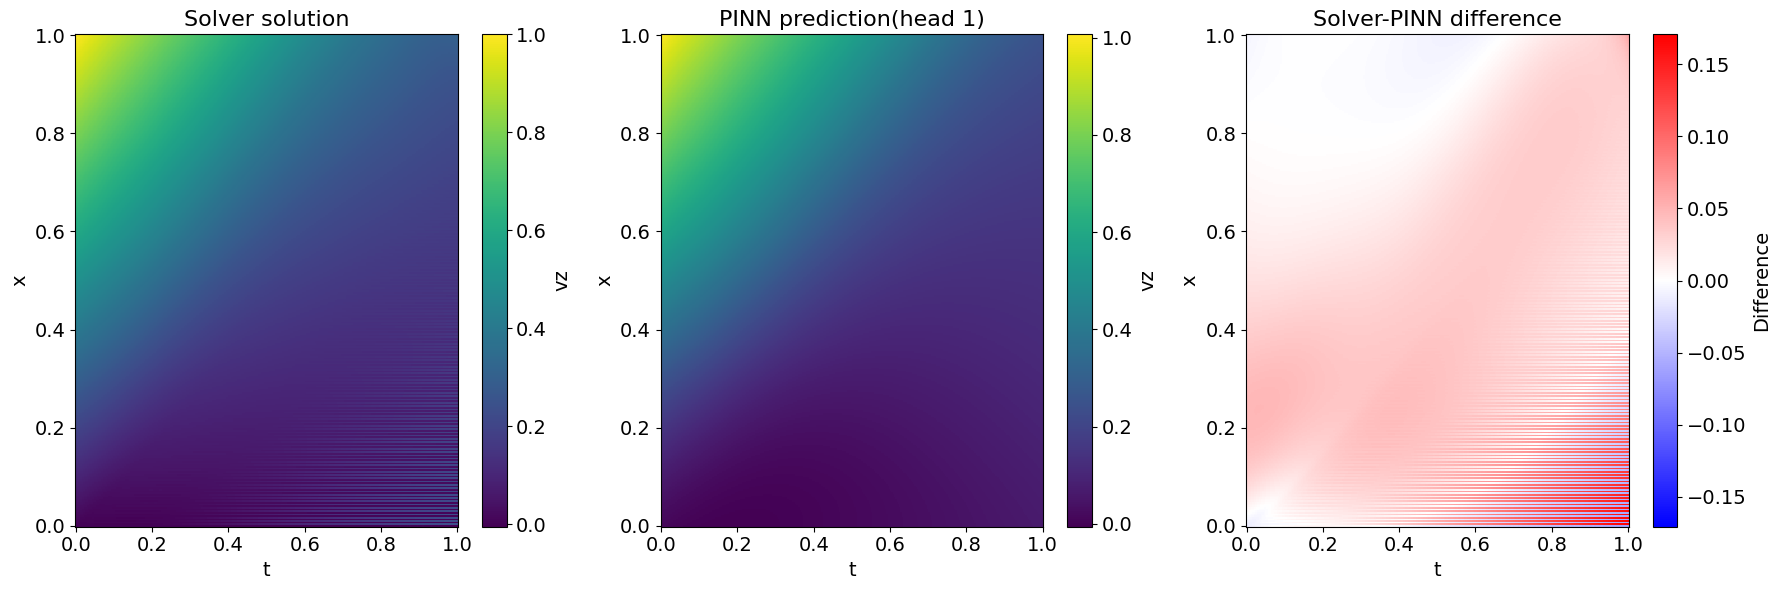

In [14]:
### solver and PINN head 1, the output can be chosen


import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import torch

# Parameters
X = 1.0       # spatial domain length
nx = 300      # number of spatial points
L = 1.0       # final duration
mu = 0.1      # viscosity

# Mesh
x = np.linspace(0, X, nx)
dx = x[1] - x[0]
t_eval = np.linspace(0, L, nx)

# Initial conditions
def init_cond():
    rho = 2*np.ones_like(x)
    vx = x
    vy = x
    vz = x
    P = np.exp(-x)
    Bx = np.exp(-x)
    By = np.exp(-x)
    Bz = np.exp(-x)
    return np.concatenate([rho, vx, vy, vz, P, Bx, By, Bz])

# Spatial derivatives (central diff, Neumann)
def d_dx(u):
    return np.gradient(u, dx)

def d2_dx2(u):
    return np.gradient(np.gradient(u, dx), dx)

# ODE system function: dy/dt = ...
def mhd_rhs(t, y):
    f = forcing_terms(x, t)  # shape (8, N)

    rho, vx, vy, vz, P, Bx, By, Bz = np.split(y, 8)

    drho_dt = -vx * d_dx(rho) - rho * d_dx(vx) 
    dvx_dt = (-vx * d_dx(vx) - (1/rho) * d_dx(P)
              - (1/rho)*(By * d_dx(By) + Bz * d_dx(Bz))
              + mu * d2_dx2(vx) )
    dvy_dt = (-vx * d_dx(vy) + (1/rho)*Bx*d_dx(By) )
    dvz_dt = (-vx * d_dx(vz) + (1/rho)*Bx*d_dx(Bz) )
    dP_dt = -P * d_dx(vx) - vx * d_dx(P) 
    dBx_dt = np.zeros_like(Bx) 
    dBy_dt = (-vx * d_dx(By) - By * d_dx(vx) + Bx * d_dx(vy) )
    dBz_dt = (-vx * d_dx(Bz) - Bz * d_dx(vx) + Bx * d_dx(vz) )

    # Direct forcing of boundary variables
    rho[0] = 2
    vx[0] = vy[0] = vz[0] = 0
    P[0] = Bx[0] = By[0] = Bz[0] = np.exp(-t)

    return np.concatenate([drho_dt, dvx_dt, dvy_dt, dvz_dt, dP_dt, dBx_dt, dBy_dt, dBz_dt])

# Resolution
y0 = init_cond()
solv1 = solve_ivp(mhd_rhs, (0, L), y0, method='RK45', t_eval=t_eval)

# Extraction of numerical vx
vx_num_v1 = solv1.y[3*nx:4*nx, :]  # shape (nx, nt), (0:nx) for rho
T, Xg = np.meshgrid(solv1.t, x)

# Exact solution (calculated but not displayed)
vx_ex = np.exp(-Xg)*np.exp(-T)
err = vx_num_v1 - vx_ex

# Data preparation for PINN
x_tensor = torch.tensor(Xg.flatten(), dtype=torch.float32).view(-1, 1)
t_tensor = torch.tensor(T.flatten(), dtype=torch.float32).view(-1, 1)

# PINN prediction (using head_idx=0 for head 1)
with torch.no_grad():
    if next(nets[1].parameters()).dtype != torch.float32:
        for net in nets:
            net.float()
    vx_pinn_flat = solutions(x_tensor, t_tensor, head_idx=0)[6].cpu().numpy().flatten() ## head 1, rho

vx_pinn = vx_pinn_flat.reshape(Xg.shape)


# Plot configuration (3 plots instead of 4)
plt.figure(figsize=(18, 6))

# Style parameters to enlarge text
fontsize = 14  # Font size for axes and labels
cbar_fontsize = 14  # Font size for colorbar
title_fontsize = 16  # Font size for titles

# Plot 1: Numerical solution
plt.subplot(1, 3, 1)
img1 = plt.pcolormesh(T, Xg, vx_num_v1, shading='auto', cmap='viridis')
cbar1 = plt.colorbar(img1)
cbar1.set_label('vz', fontsize=cbar_fontsize)
cbar1.ax.tick_params(labelsize=cbar_fontsize)
plt.xlabel('t', fontsize=fontsize)
plt.ylabel('x', fontsize=fontsize)
plt.title('Solver solution', fontsize=title_fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)

# Plot 2: PINN prediction
plt.subplot(1, 3, 2)
img2 = plt.pcolormesh(T, Xg, vx_pinn, shading='auto', cmap='viridis')
cbar2 = plt.colorbar(img2)
cbar2.set_label('vz', fontsize=cbar_fontsize)
cbar2.ax.tick_params(labelsize=cbar_fontsize)
plt.xlabel('t', fontsize=fontsize)
plt.ylabel('x', fontsize=fontsize)
plt.title('PINN prediction(head 1)', fontsize=title_fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)

# Plot 3: Solver-PINN difference
plt.subplot(1, 3, 3)
diff = vx_num_v1 - vx_pinn
img3 = plt.pcolormesh(T, Xg, diff, shading='auto', cmap='bwr',
               vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)))
cbar3 = plt.colorbar(img3)
cbar3.set_label('Difference', fontsize=cbar_fontsize)
cbar3.ax.tick_params(labelsize=cbar_fontsize)
plt.xlabel('t', fontsize=fontsize)
plt.ylabel('x', fontsize=fontsize)
plt.title('Solver-PINN difference', fontsize=title_fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)

plt.tight_layout()
plt.show()

In [12]:
## TL on CIs (new head head3 initialized on head2)
## without ff, with BC

from neurodiffeq.operators import diff  # Crucial import for derivatives


class MultiHeadFCNN(nn.Module):
    def __init__(self, n_input_units=2, n_output_units=1, hidden_units=[256, 256]):
        super().__init__()
        # Shared layers (unchanged)
        self.shared_layers = nn.Sequential(
            nn.Linear(n_input_units, hidden_units[0]),
            nn.Tanh(),
            nn.Linear(hidden_units[0], hidden_units[1]),
            nn.Tanh()
        )
        
        # Existing heads (head1, head2) + new head (head3)
        self.head1 = nn.Linear(hidden_units[1], n_output_units)
        self.head2 = nn.Linear(hidden_units[1], n_output_units)
        self.head3 = nn.Linear(hidden_units[1], n_output_units)  # New head for new CIs

    def forward(self, x, head_idx=2):  # head_idx=2 by default (head3)
        shared = self.shared_layers(x)
        if head_idx == 0:
            return self.head1(shared)
        elif head_idx == 1:
            return self.head2(shared)
        else:
            return self.head3(shared)


## Network initialization for transfer learning
nets = []
total_losses = []
pde_losses = []
ic_losses = []
bc_losses = []  # To track boundary conditions loss

## New initial condition for head3
new_initial_conditions = {
    'rho': lambda x: 2*torch.ones_like(x),
    'v': lambda x: x*x,
    'P': lambda x: torch.exp(-x),
    'By': lambda x: torch.exp(-x),
    'Bz': lambda x: torch.exp(-x),
    'vy': lambda x: x*x,
    'vz': lambda x: x*x,
    'Bx': lambda x: torch.exp(-x)
}

## Boundary conditions
def boundary_conditions(t):
    """Returns target values for x=0"""
    return {
        'rho': 2.0 * torch.ones_like(t),
        'v': torch.zeros_like(t),
        'vy': torch.zeros_like(t),
        'vz': torch.zeros_like(t),
        'P': torch.exp(-t),
        'Bx': torch.exp(-t),
        'By': torch.exp(-t),
        'Bz': torch.exp(-t)
    }

## Loading pre-trained weights
for i in range(8):
    net = MultiHeadFCNN(n_input_units=2, n_output_units=1, hidden_units=[256, 256])
    
    # Load existing weights
    pretrained_dict = torch.load(f"saved_weights/net_{i}.pt", map_location='cpu')
    model_dict = net.state_dict()
    
    # Copy shared layers + head1 + head2
    model_dict.update(pretrained_dict)

    # Initialize head3 with head2
    for name, param in pretrained_dict.items():
        if name.startswith("head2."):
            corresponding_name = name.replace("head2.", "head3.")
            if corresponding_name in model_dict:
                model_dict[corresponding_name] = param.clone()

    net.load_state_dict(model_dict, strict=False)
    nets.append(net)

## Only head3 is trainable
for net in nets:
    for name, param in net.named_parameters():
        param.requires_grad = ('head3' in name)

## Optimizer
optimizer = optim.Adam([p for net in nets for p in net.parameters() if p.requires_grad], lr=1e-4)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.975)

## PDE system without forcing
def pde_systemTL(rho, vx, P, By, Bz, vy, vz, Bx, x, t):
    # Convert inputs to tensors if necessary
    if not isinstance(x, torch.Tensor):
        x = torch.tensor(x, dtype=torch.float32, requires_grad=True)
    if not isinstance(t, torch.Tensor):
        t = torch.tensor(t, dtype=torch.float32, requires_grad=True)
    
    # Ensure all variables are tensors with grad
    variables = [rho, vx, P, By, Bz, vy, vz, Bx]
    for i, var in enumerate(variables):
        if not isinstance(var, torch.Tensor):
            variables[i] = torch.tensor(var, dtype=torch.float32, requires_grad=True)
    rho, vx, P, By, Bz, vy, vz, Bx = variables
    
    # Calculation of PDE equations
    eq1 = diff(rho, t) + vx * diff(rho, x) + rho * diff(vx, x)
    eq2 = rho * diff(vx, t) + rho * vx * diff(vx, x) + diff(P, x) + By * diff(By, x) + Bz * diff(Bz, x) - rho * mu * diff(vx, x, order=2)
    eq3 = rho * diff(vy, t) + rho * vx * diff(vy, x) - Bx * diff(By, x)
    eq4 = rho * diff(vz, t) + rho * vx * diff(vz, x) - Bx * diff(Bz, x)
    eq5 = diff(P, t) + P * diff(vx, x) + vx * diff(P, x)
    eq6 = diff(Bx, t)
    eq7 = diff(By, t) + vx * diff(By, x) + By * diff(vx, x) - Bx * diff(vy, x)
    eq8 = diff(Bz, t) + vx * diff(Bz, x) + Bz * diff(vx, x) - Bx * diff(vz, x)
    
    return [eq1, eq2, eq3, eq4, eq5, eq6, eq7, eq8]


## Training
n_epochs = 12000
print_interval = n_epochs // 10  # Display every 10% progress

for epoch in tqdm(range(n_epochs)):
    optimizer.zero_grad()
    total_loss = 0
    
    # 1. PDE Loss
    samples = train_gen.get_examples()
    x_train = samples[0].view(-1, 1)
    t_train = samples[1].view(-1, 1)
    inputs = torch.cat((x_train, t_train), dim=1)
    
    outputs = [net(inputs, head_idx=2) for net in nets]  # Using head3
    
    pde_residuals = pde_systemTL(*outputs, x_train, t_train)
    loss_pde = sum([criterion(res, torch.zeros_like(res)) for res in pde_residuals])
    
    # 2. Initial condition loss
    ic_inputs = torch.cat((ic_x, ic_t), dim=1)
    ic_outputs = [net(ic_inputs, head_idx=2) for net in nets]
    ic_targets = [new_initial_conditions[key](ic_x) for key in ['rho', 'v', 'P', 'By', 'Bz', 'vy', 'vz', 'Bx']]
    loss_ic = sum([criterion(out, target) for out, target in zip(ic_outputs, ic_targets)])
    
    # 3. Boundary condition loss (x=0)
    bc_samples = bc_gen.get_examples()
    x_bc = torch.zeros_like(bc_samples[0]).view(-1, 1)  # x=0
    t_bc = bc_samples[1].view(-1, 1)
    bc_inputs = torch.cat((x_bc, t_bc), dim=1)
    
    bc_outputs = [net(bc_inputs, head_idx=2) for net in nets]
    bc_targets = boundary_conditions(t_bc)
    loss_bc = sum([
        criterion(bc_outputs[0], bc_targets['rho']),
        criterion(bc_outputs[1], bc_targets['v']),
        criterion(bc_outputs[2], bc_targets['P']),
        criterion(bc_outputs[3], bc_targets['By']),
        criterion(bc_outputs[4], bc_targets['Bz']),
        criterion(bc_outputs[5], bc_targets['vy']),
        criterion(bc_outputs[6], bc_targets['vz']),
        criterion(bc_outputs[7], bc_targets['Bx'])
    ])
    
    # Total loss
    total_loss = loss_pde + loss_ic + loss_bc
    total_loss.backward()
    optimizer.step()
    scheduler.step()
   
    # Only display every 10% progress
    if (epoch + 1) % print_interval == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{n_epochs} ({100*(epoch+1)/n_epochs:.0f}%) | "
              f"PDE: {loss_pde.item():.3e} | "
              f"IC: {loss_ic.item():.3e} | "
              f"BC: {loss_bc.item():.3e} | "
              f"Total: {total_loss.item():.3e}")
    
    total_losses.append(total_loss.item())
    pde_losses.append(loss_pde.item())
    ic_losses.append(loss_ic.item())
    bc_losses.append(loss_bc.item())

# For evaluation
def solutions_new_ci(x, t):
    return [net(torch.cat((x, t), dim=1), head_idx=2).detach() for net in nets]

  0%|          | 1/12000 [00:00<23:45,  8.42it/s]

Epoch 1/12000 (0%) | PDE: 3.060e-01 | IC: 2.978e-01 | BC: 6.462e-03 | Total: 6.103e-01


 10%|█         | 1201/12000 [02:27<21:55,  8.21it/s]

Epoch 1200/12000 (10%) | PDE: 2.060e-02 | IC: 4.012e-03 | BC: 7.659e-03 | Total: 3.228e-02


 20%|██        | 2401/12000 [04:59<19:37,  8.15it/s]

...

Epoch 9600/12000 (80%) | PDE: 1.066e-02 | IC: 1.388e-03 | BC: 6.547e-03 | Total: 1.860e-02


 90%|█████████ | 10801/12000 [22:47<02:29,  8.04it/s]

Epoch 10800/12000 (90%) | PDE: 1.142e-02 | IC: 1.352e-03 | BC: 6.462e-03 | Total: 1.924e-02


100%|██████████| 12000/12000 [25:16<00:00,  7.91it/s]

Epoch 12000/12000 (100%) | PDE: 1.070e-02 | IC: 1.312e-03 | BC: 6.537e-03 | Total: 1.855e-02


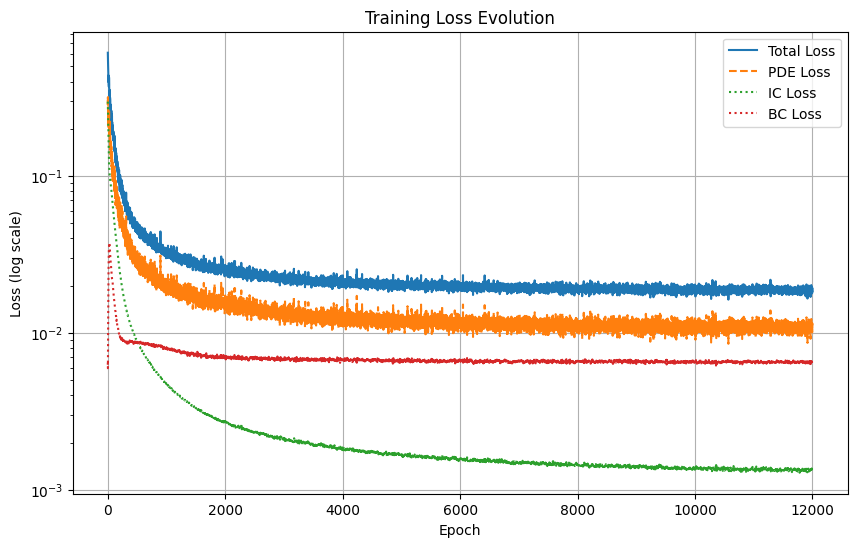

In [13]:
## show loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.semilogy(total_losses, label='Total Loss')
plt.semilogy(pde_losses, label='PDE Loss', linestyle='--')
plt.semilogy(ic_losses, label='IC Loss', linestyle=':')
plt.semilogy(bc_losses, label='BC Loss', linestyle=':')


plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Training Loss Evolution')
plt.legend()
plt.grid(True)
plt.show()

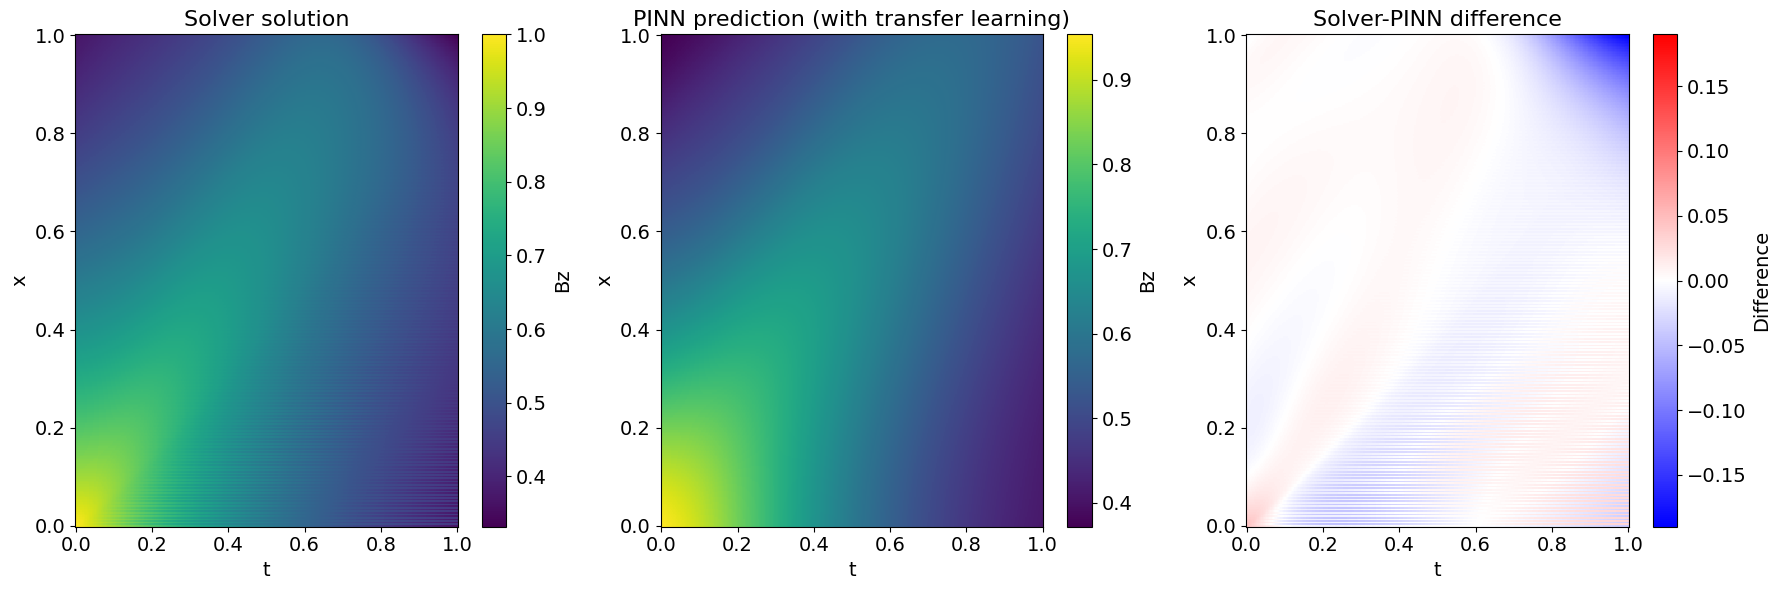

In [15]:
### solver and PINN head 1
## the output can be chosen


import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import torch

# Parameters
X = 1.0       # spatial domain length
nx = 300      # number of spatial points
L = 1.0       # final duration
mu = 0.1      # viscosity

# Mesh
x = np.linspace(0, X, nx)
dx = x[1] - x[0]
t_eval = np.linspace(0, L, nx)

# Initial conditions
def init_cond():
    rho = 2*np.ones_like(x)
    vx = x*x
    vy = x*x
    vz = x*x
    P = np.exp(-x)
    Bx = np.exp(-x)
    By = np.exp(-x)
    Bz = np.exp(-x)
    return np.concatenate([rho, vx, vy, vz, P, Bx, By, Bz])

# Spatial derivatives (central diff, Neumann)
def d_dx(u):
    return np.gradient(u, dx)

def d2_dx2(u):
    return np.gradient(np.gradient(u, dx), dx)

# ODE system function: dy/dt = ...
def mhd_rhs(t, y):
    f = forcing_terms(x, t)  # shape (8, N)

    rho, vx, vy, vz, P, Bx, By, Bz = np.split(y, 8)

    drho_dt = -vx * d_dx(rho) - rho * d_dx(vx) 
    dvx_dt = (-vx * d_dx(vx) - (1/rho) * d_dx(P)
              - (1/rho)*(By * d_dx(By) + Bz * d_dx(Bz))
              + mu * d2_dx2(vx) )
    dvy_dt = (-vx * d_dx(vy) + (1/rho)*Bx*d_dx(By) )
    dvz_dt = (-vx * d_dx(vz) + (1/rho)*Bx*d_dx(Bz) )
    dP_dt = -P * d_dx(vx) - vx * d_dx(P) 
    dBx_dt = np.zeros_like(Bx) 
    dBy_dt = (-vx * d_dx(By) - By * d_dx(vx) + Bx * d_dx(vy) )
    dBz_dt = (-vx * d_dx(Bz) - Bz * d_dx(vx) + Bx * d_dx(vz) )

    # Direct forcing of boundary variables
    rho[0] = 2
    vx[0] = vy[0] = vz[0] = 0
    P[0] = Bx[0] = By[0] = Bz[0] = np.exp(-t)

    return np.concatenate([drho_dt, dvx_dt, dvy_dt, dvz_dt, dP_dt, dBx_dt, dBy_dt, dBz_dt])

# Resolution
y0 = init_cond()
solv1 = solve_ivp(mhd_rhs, (0, L), y0, method='RK45', t_eval=t_eval)

# Extraction of numerical vx
vx_num_v1 = solv1.y[7*nx:8*nx, :]  # shape (nx, nt), (0:nx) for rho
T, Xg = np.meshgrid(solv1.t, x)

# Exact solution (calculated but not displayed)
vx_ex = np.exp(-Xg)*np.exp(-T)
err = vx_num_v1 - vx_ex

# Data preparation for PINN
x_tensor = torch.tensor(Xg.flatten(), dtype=torch.float32).view(-1, 1)
t_tensor = torch.tensor(T.flatten(), dtype=torch.float32).view(-1, 1)

# PINN prediction (using head_idx=2 for head 3)
with torch.no_grad():
    if next(nets[1].parameters()).dtype != torch.float32:
        for net in nets:
            net.float()
    vx_pinn_flat = solutions(x_tensor, t_tensor, head_idx=2)[4].cpu().numpy().flatten() ## head 1, rho

vx_pinn = vx_pinn_flat.reshape(Xg.shape)


# Plot configuration (3 plots instead of 4)
plt.figure(figsize=(18, 6))

# Style parameters to enlarge text
fontsize = 14  # Font size for axes and labels
cbar_fontsize = 14  # Font size for colorbar
title_fontsize = 16  # Font size for titles

# Plot 1: Numerical solution
plt.subplot(1, 3, 1)
img1 = plt.pcolormesh(T, Xg, vx_num_v1, shading='auto', cmap='viridis')
cbar1 = plt.colorbar(img1)
cbar1.set_label('Bz', fontsize=cbar_fontsize)
cbar1.ax.tick_params(labelsize=cbar_fontsize)
plt.xlabel('t', fontsize=fontsize)
plt.ylabel('x', fontsize=fontsize)
plt.title('Solver solution', fontsize=title_fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)

# Plot 2: PINN prediction
plt.subplot(1, 3, 2)
img2 = plt.pcolormesh(T, Xg, vx_pinn, shading='auto', cmap='viridis')
cbar2 = plt.colorbar(img2)
cbar2.set_label('Bz', fontsize=cbar_fontsize)
cbar2.ax.tick_params(labelsize=cbar_fontsize)
plt.xlabel('t', fontsize=fontsize)
plt.ylabel('x', fontsize=fontsize)
plt.title('PINN prediction (with transfer learning)', fontsize=title_fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)

# Plot 3: Solver-PINN difference
plt.subplot(1, 3, 3)
diff = vx_num_v1 - vx_pinn
img3 = plt.pcolormesh(T, Xg, diff, shading='auto', cmap='bwr',
               vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)))
cbar3 = plt.colorbar(img3)
cbar3.set_label('Difference', fontsize=cbar_fontsize)
cbar3.ax.tick_params(labelsize=cbar_fontsize)
plt.xlabel('t', fontsize=fontsize)
plt.ylabel('x', fontsize=fontsize)
plt.title('Solver-PINN difference', fontsize=title_fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)

plt.tight_layout()
plt.show()

In [17]:
## L-BFGS method
# TL on the CI (new head : head3 initialized on head2)
## without ff, with BC



from neurodiffeq.operators import diff  # Crucial import for derivatives


class MultiHeadFCNN(nn.Module):
    def __init__(self, n_input_units=2, n_output_units=1, hidden_units=[256, 256]):
        super().__init__()
        # Shared layers (unchanged)
        self.shared_layers = nn.Sequential(
            nn.Linear(n_input_units, hidden_units[0]),
            nn.Tanh(),
            nn.Linear(hidden_units[0], hidden_units[1]),
            nn.Tanh()
        )
        
        # Existing heads (head1, head2) + new head (head3)
        self.head1 = nn.Linear(hidden_units[1], n_output_units)
        self.head2 = nn.Linear(hidden_units[1], n_output_units)
        self.head3 = nn.Linear(hidden_units[1], n_output_units)  # New head for new ICs

    def forward(self, x, head_idx=2):  # head_idx=2 by default (head3)
        shared = self.shared_layers(x)
        if head_idx == 0:
            return self.head1(shared)
        elif head_idx == 1:
            return self.head2(shared)
        else:
            return self.head3(shared)


## Initialization of networks for transfer learning
nets = []
total_losses = []
pde_losses = []
ic_losses = []
bc_losses = []  # To track boundary conditions loss

## New initial condition for head3
new_initial_conditions = {
    'rho': lambda x: 2*torch.ones_like(x),
    'v': lambda x: x*x,
    'P': lambda x: torch.exp(-x),
    'By': lambda x: torch.exp(-x),
    'Bz': lambda x: torch.exp(-x),
    'vy': lambda x: x*x,
    'vz': lambda x: x*x,
    'Bx': lambda x: torch.exp(-x)
}

## Boundary conditions
def boundary_conditions(t):
    """Returns target values for x=0"""
    return {
        'rho': 2.0 * torch.ones_like(t),
        'v': torch.zeros_like(t),
        'vy': torch.zeros_like(t),
        'vz': torch.zeros_like(t),
        'P': torch.exp(-t),
        'Bx': torch.exp(-t),
        'By': torch.exp(-t),
        'Bz': torch.exp(-t)
    }

## Loading pre-trained weights
for i in range(8):
    net = MultiHeadFCNN(n_input_units=2, n_output_units=1, hidden_units=[256, 256])
    
    # Load existing weights
    pretrained_dict = torch.load(f"saved_weights/net_{i}.pt", map_location='cpu')
    model_dict = net.state_dict()
    
    # Copy shared layers + head1 + head2
    model_dict.update(pretrained_dict)

    # Initialize head3 with head2
    for name, param in pretrained_dict.items():
        if name.startswith("head2."):
            corresponding_name = name.replace("head2.", "head3.")
            if corresponding_name in model_dict:
                model_dict[corresponding_name] = param.clone()

    net.load_state_dict(model_dict, strict=False)
    nets.append(net)

## Only head3 is trainable
for net in nets:
    for name, param in net.named_parameters():
        param.requires_grad = ('head3' in name)

## Optimizer

optimizer = optim.LBFGS(
    [p for net in nets for p in net.parameters() if p.requires_grad],
    lr=0.01,              # Reduced for better stability
    max_iter=10, 
    history_size=50,          # Avoid over-optimization
    line_search_fn='strong_wolfe'    # None to disable if unstable
)

criterion = nn.MSELoss()
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.975)

## PDE system without forcing
def pde_systemTL(rho, vx, P, By, Bz, vy, vz, Bx, x, t):
    # No .detach() here - all tensors must be differentiable
    eq1 = diff(rho, t) + vx * diff(rho, x) + rho * diff(vx, x)
    eq2 = rho * diff(vx, t) + rho * vx * diff(vx, x) + diff(P, x) + By * diff(By, x) + Bz * diff(Bz, x) - rho * mu * diff(vx, x, order=2)
    eq3 = rho * diff(vy, t) + rho * vx * diff(vy, x) - Bx * diff(By, x)
    eq4 = rho * diff(vz, t) + rho * vx * diff(vz, x) - Bx * diff(Bz, x)
    eq5 = diff(P, t) + P * diff(vx, x) + vx * diff(P, x)
    eq6 = diff(Bx, t)
    eq7 = diff(By, t) + vx * diff(By, x) + By * diff(vx, x) - Bx * diff(vy, x)
    eq8 = diff(Bz, t) + vx * diff(Bz, x) + Bz * diff(vx, x) - Bx * diff(vz, x)
    
    return [eq1, eq2, eq3, eq4, eq5, eq6, eq7, eq8]


## Training
n_epochs = 150
print_interval = n_epochs // 10  # Display every 10% progress

def closure():
    optimizer.zero_grad()
    
    # Data regeneration INSIDE the closure
    samples = train_gen.get_examples()
    x_train = samples[0].view(-1, 1).requires_grad_(True)
    t_train = samples[1].view(-1, 1).requires_grad_(True)
    inputs = torch.cat((x_train, t_train), dim=1)
    
    # Forward pass
    outputs = []
    for net in nets:
        out = net(inputs, head_idx=2)
        if not out.requires_grad:
            out = out.clone().detach().requires_grad_(True)
        outputs.append(out)
    
    # Calculation of PDE residuals
    train_residuals = pde_systemTL(*outputs, x_train, t_train)
    loss_pde = sum([criterion(res, torch.zeros_like(res)) for res in train_residuals])

    # Calculation of other losses
    ic_inputs = torch.cat((ic_x, ic_t), dim=1)
    ic_outputs = [net(ic_inputs, head_idx=2) for net in nets]
    ic_targets = [new_initial_conditions[key](ic_x) for key in ['rho', 'v', 'P', 'By', 'Bz', 'vy', 'vz', 'Bx']]
    loss_ic = sum([criterion(out, target) for out, target in zip(ic_outputs, ic_targets)])
    
    bc_samples = bc_gen.get_examples()
    x_bc = torch.zeros_like(bc_samples[0]).view(-1, 1).requires_grad_(True)
    t_bc = bc_samples[1].view(-1, 1).requires_grad_(True)
    bc_inputs = torch.cat((x_bc, t_bc), dim=1)
    bc_outputs = [net(bc_inputs, head_idx=2) for net in nets]
    bc_targets = boundary_conditions(t_bc)
    loss_bc = sum([criterion(bc_outputs[i], bc_targets[key]) 
                  for i, key in enumerate(['rho', 'v', 'P', 'By', 'Bz', 'vy', 'vz', 'Bx'])])
    
    total_loss = loss_pde + loss_ic + loss_bc
    total_loss.backward()

    return total_loss


for epoch in tqdm(range(n_epochs)):
    # L-BFGS step
    optimizer.step(closure)
    
    # Periodic display
    if (epoch + 1) % print_interval == 0 or epoch == 0:
        # We must keep gradients for PDE residuals calculation
        with torch.enable_grad():  # <-- Crucial change here
            samples = train_gen.get_examples()
            x_train = samples[0].view(-1, 1).requires_grad_(True)  # <-- Added requires_grad
            t_train = samples[1].view(-1, 1).requires_grad_(True)  # <-- Added requires_grad
            inputs = torch.cat((x_train, t_train), dim=1)
            
            outputs = [net(inputs, head_idx=2) for net in nets]
            pde_residuals = pde_systemTL(*outputs, x_train, t_train)
            
            # Loss calculation with no_grad for evaluation only
            with torch.no_grad():
                loss_pde = sum([criterion(res, torch.zeros_like(res)) for res in pde_residuals]).item()
                ic_outputs = [net(ic_inputs, head_idx=2) for net in nets]
                loss_ic = sum([criterion(out, target) for out, target in zip(ic_outputs, ic_targets)]).item()
                
                bc_outputs = [net(bc_inputs, head_idx=2) for net in nets]
                loss_bc = sum([criterion(bc_outputs[i], bc_targets[key]) 
                             for i, key in enumerate(['rho', 'v', 'P', 'By', 'Bz', 'vy', 'vz', 'Bx'])]).item()
                
                total_loss = loss_pde + loss_ic + loss_bc
                print(f"Epoch {epoch+1}/{n_epochs} ({100*(epoch+1)/n_epochs:.0f}%) | "
                      f"PDE: {loss_pde:.3e} | "
                      f"IC: {loss_ic:.3e} | "
                      f"BC: {loss_bc:.3e} | "
                      f"Total: {total_loss:.3e}")
                
                print("Residuals:", [r.mean().item() for r in pde_residuals])
        
        # Saving losses
        total_losses.append(total_loss)
        pde_losses.append(loss_pde)
        ic_losses.append(loss_ic)
        bc_losses.append(loss_bc)

    


# For evaluation
def solutions_new_ci(x, t):
    return [net(torch.cat((x, t), dim=1), head_idx=2).detach() for net in nets]

  1%|          | 1/150 [00:01<03:32,  1.43s/it]

Epoch 1/150 (1%) | PDE: 3.100e-01 | IC: 2.975e-01 | BC: 6.445e-03 | Total: 6.140e-01
Residuals: [-0.005552329381750182, 0.24804781406922363, -0.0025799437826244725, -0.002809296568895001, -0.0055758533076412705, -0.01907993663494687, -0.004233341252246353, -0.004635563685453101]


 10%|█         | 15/150 [00:11<01:27,  1.55it/s]

Epoch 15/150 (10%) | PDE: 3.135e-01 | IC: 2.974e-01 | BC: 6.440e-03 | Total: 6.173e-01
Residuals: [-0.005026235721841338, 0.2459539750817584, -0.002523788086329762, -0.0025066666658101074, -0.004735541567543831, -0.018632534993709857, -0.003450718295148518, -0.0037824300086881156]


 20%|██        | 30/150 [00:23<01:55,  1.04it/s]

...

Epoch 120/150 (80%) | PDE: 2.384e-01 | IC: 9.171e-02 | BC: 1.162e-02 | Total: 3.417e-01
Residuals: [0.014860576671874173, 0.1629678920119636, -0.012017863715289623, -0.0030511764084216767, -0.013108986532194403, -0.022084797042662783, -0.011218562836221725, -0.011588219259845114]


 90%|█████████ | 135/150 [02:19<00:20,  1.36s/it]

Epoch 135/150 (90%) | PDE: 2.797e-01 | IC: 8.822e-02 | BC: 1.191e-02 | Total: 3.798e-01
Residuals: [0.01594878044805154, 0.17295367361033454, -0.01154897484512424, -0.0027081749104230935, -0.015009713911562955, -0.02225836104099539, -0.012321850014311776, -0.012615946320844965]


100%|██████████| 150/150 [02:36<00:00,  1.05s/it]

Epoch 150/150 (100%) | PDE: 2.431e-01 | IC: 8.731e-02 | BC: 1.202e-02 | Total: 3.424e-01
Residuals: [0.015433771623711557, 0.1661152686564974, -0.010358310820934689, -0.0017199119979384202, -0.014040841147316026, -0.024905969855867797, -0.011519064983920928, -0.011739115069709132]


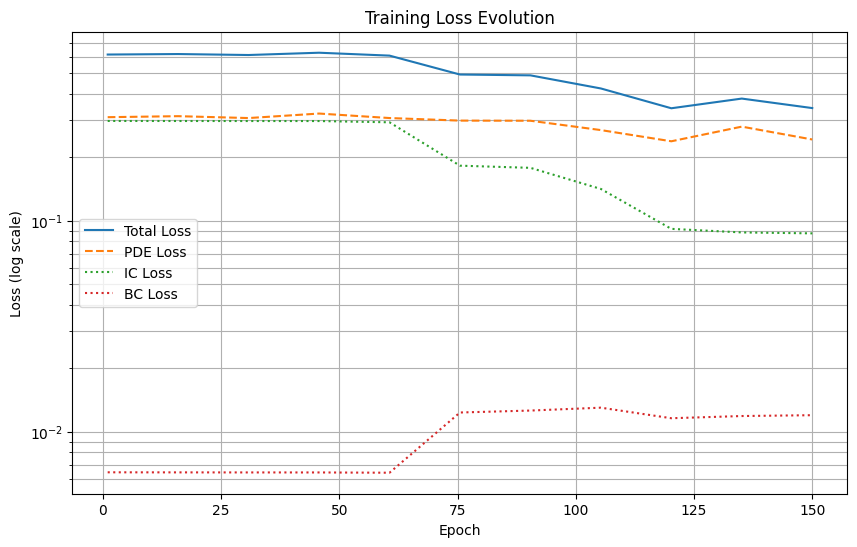

In [18]:
## loss for LBFGS method

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Creating correct x-axis values (from 1 to 150)
epochs = np.linspace(1, 150, len(total_losses))  # Adjusts the scale

plt.semilogy(epochs, total_losses, label='Total Loss')
plt.semilogy(epochs, pde_losses, label='PDE Loss', linestyle='--')
plt.semilogy(epochs, ic_losses, label='IC Loss', linestyle=':')
plt.semilogy(epochs, bc_losses, label='BC Loss', linestyle=':')

plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Training Loss Evolution')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.xticks(np.arange(0, 151, 25))  # Graduations every 25 epochs
plt.show()

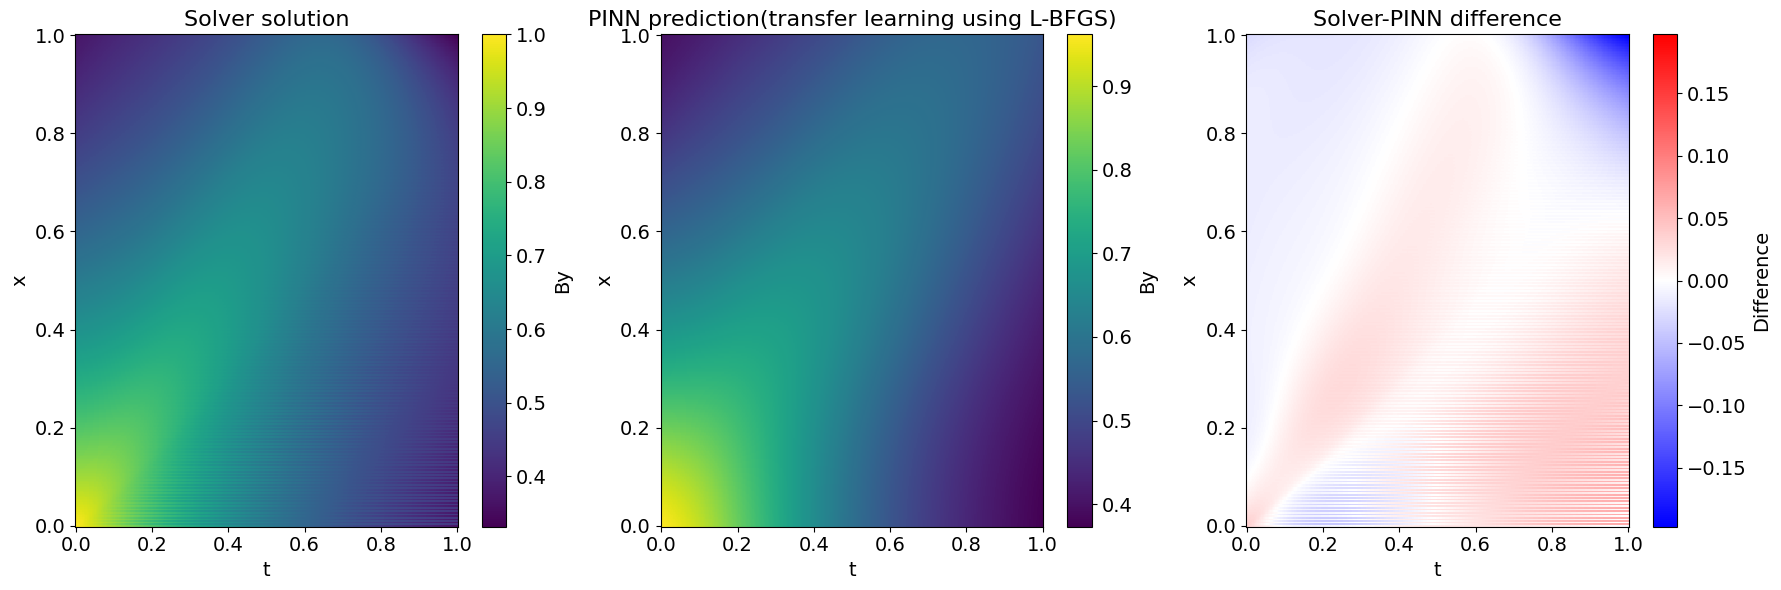

In [19]:
## L-BFGS method
## solver and PINN head 1
## output must be adapted to your need

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import torch

# Parameters
X = 1.0       # spatial domain length
nx = 300      # number of spatial points
L = 1.0       # final duration
mu = 0.1      # viscosity

# Mesh
x = np.linspace(0, X, nx)
dx = x[1] - x[0]
t_eval = np.linspace(0, L, nx)

# Initial conditions
def init_cond():
    rho = 2*np.ones_like(x)
    vx = x*x
    vy = x*x
    vz = x*x
    P = np.exp(-x)
    Bx = np.exp(-x)
    By = np.exp(-x)
    Bz = np.exp(-x)
    return np.concatenate([rho, vx, vy, vz, P, Bx, By, Bz])

# Spatial derivatives (central diff, Neumann)
def d_dx(u):
    return np.gradient(u, dx)

def d2_dx2(u):
    return np.gradient(np.gradient(u, dx), dx)

# ODE system function: dy/dt = ...
def mhd_rhs(t, y):
    f = forcing_terms(x, t)  # shape (8, N)

    rho, vx, vy, vz, P, Bx, By, Bz = np.split(y, 8)

    drho_dt = -vx * d_dx(rho) - rho * d_dx(vx) 
    dvx_dt = (-vx * d_dx(vx) - (1/rho) * d_dx(P)
              - (1/rho)*(By * d_dx(By) + Bz * d_dx(Bz))
              + mu * d2_dx2(vx) )
    dvy_dt = (-vx * d_dx(vy) + (1/rho)*Bx*d_dx(By) )
    dvz_dt = (-vx * d_dx(vz) + (1/rho)*Bx*d_dx(Bz) )
    dP_dt = -P * d_dx(vx) - vx * d_dx(P) 
    dBx_dt = np.zeros_like(Bx) 
    dBy_dt = (-vx * d_dx(By) - By * d_dx(vx) + Bx * d_dx(vy) )
    dBz_dt = (-vx * d_dx(Bz) - Bz * d_dx(vx) + Bx * d_dx(vz) )

    # Direct forcing of boundary variables
    rho[0] = 2
    vx[0] = vy[0] = vz[0] = 0
    P[0] = Bx[0] = By[0] = Bz[0] = np.exp(-t)

    return np.concatenate([drho_dt, dvx_dt, dvy_dt, dvz_dt, dP_dt, dBx_dt, dBy_dt, dBz_dt])

# Resolution
y0 = init_cond()
solv1 = solve_ivp(mhd_rhs, (0, L), y0, method='RK45', t_eval=t_eval)

# Extraction of numerical vx (using By index range)
vx_num_v1 = solv1.y[6*nx:7*nx, :]  # shape (nx, nt), (0:nx) for rho
T, Xg = np.meshgrid(solv1.t, x)

# Exact solution (calculated but not displayed)
vx_ex = np.exp(-Xg)*np.exp(-T)
err = vx_num_v1 - vx_ex

# Data preparation for PINN
x_tensor = torch.tensor(Xg.flatten(), dtype=torch.float32).view(-1, 1)
t_tensor = torch.tensor(T.flatten(), dtype=torch.float32).view(-1, 1)

# PINN prediction (using head_idx=2 for head 3)
with torch.no_grad():
    if next(nets[1].parameters()).dtype != torch.float32:
        for net in nets:
            net.float()
    vx_pinn_flat = solutions(x_tensor, t_tensor, head_idx=2)[3].cpu().numpy().flatten() ## head 1, rho

vx_pinn = vx_pinn_flat.reshape(Xg.shape)


# Plot configuration (3 plots instead of 4)
plt.figure(figsize=(18, 6))

# Style parameters to enlarge text
fontsize = 14  # Font size for axes and titles
cbar_fontsize = 14  # Font size for colorbar
title_fontsize = 16  # Font size for titles

# Plot 1: Numerical solution
plt.subplot(1, 3, 1)
img1 = plt.pcolormesh(T, Xg, vx_num_v1, shading='auto', cmap='viridis')
cbar1 = plt.colorbar(img1)
cbar1.set_label('By', fontsize=cbar_fontsize)
cbar1.ax.tick_params(labelsize=cbar_fontsize)
plt.xlabel('t', fontsize=fontsize)
plt.ylabel('x', fontsize=fontsize)
plt.title('Solver solution', fontsize=title_fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)

# Plot 2: PINN prediction
plt.subplot(1, 3, 2)
img2 = plt.pcolormesh(T, Xg, vx_pinn, shading='auto', cmap='viridis')
cbar2 = plt.colorbar(img2)
cbar2.set_label('By', fontsize=cbar_fontsize)
cbar2.ax.tick_params(labelsize=cbar_fontsize)
plt.xlabel('t', fontsize=fontsize)
plt.ylabel('x', fontsize=fontsize)
plt.title('PINN prediction(transfer learning using L-BFGS)', fontsize=title_fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)

# Plot 3: Solver-PINN difference
plt.subplot(1, 3, 3)
diff = vx_num_v1 - vx_pinn
img3 = plt.pcolormesh(T, Xg, diff, shading='auto', cmap='bwr',
               vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)))
cbar3 = plt.colorbar(img3)
cbar3.set_label('Difference', fontsize=cbar_fontsize)
cbar3.ax.tick_params(labelsize=cbar_fontsize)
plt.xlabel('t', fontsize=fontsize)
plt.ylabel('x', fontsize=fontsize)
plt.title('Solver-PINN difference', fontsize=title_fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)

plt.tight_layout()
plt.show()